In [1]:
import pandas as pd
import numpy as np
import ast
import joblib
import os

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)


In [2]:
ptb_df = pd.read_csv("/Users/tejas/Documents/C_ML/Heart_disease_CML/data/ptb_xl/ptbxl_database.csv")
scp_df = pd.read_csv("/Users/tejas/Documents/C_ML/Heart_disease_CML/data/ptb_xl/scp_statements.csv", index_col=0)

print(f"PTB-XL: {ptb_df.shape}")
print(f"SCP statements: {scp_df.shape}")



PTB-XL: (21799, 28)
SCP statements: (71, 12)


In [3]:
scp_diag = scp_df[scp_df["diagnostic"] == 1]
scp_to_superclass = scp_diag["diagnostic_class"].to_dict()
print(f"Diagnostic SCP codes: {len(scp_to_superclass)}")


Diagnostic SCP codes: 44


In [ ]:
# Parse scp_codes: could be string or already dict
if isinstance(ptb_df["scp_codes"].iloc[0], str):
    ptb_df["scp_codes"] = ptb_df["scp_codes"].apply(ast.literal_eval)

def get_superclass(scp_dict):
    for code in scp_dict.keys():
        if code in scp_to_superclass:
            return scp_to_superclass[code]
    return "OTHER"

ptb_df["diagnostic_superclass"] = ptb_df["scp_codes"].apply(get_superclass)

# Extract SCP likelihood features (NOT mi_likelihood to avoid leakage) ──
norm_codes = set(scp_diag[scp_diag["diagnostic_class"] == "NORM"].index)
sttc_codes = set(scp_diag[scp_diag["diagnostic_class"] == "STTC"].index)
hyp_codes = set(scp_diag[scp_diag["diagnostic_class"] == "HYP"].index)
cd_codes = set(scp_diag[scp_diag["diagnostic_class"] == "CD"].index)

def max_likelihood(scp_dict, target_codes):
    return max([scp_dict.get(c, 0) for c in target_codes], default=0)

# NOTE: mi_likelihood deliberately excluded — it leaks the target label
ptb_df["norm_likelihood"] = ptb_df["scp_codes"].apply(lambda x: max_likelihood(x, norm_codes))
ptb_df["sttc_likelihood"] = ptb_df["scp_codes"].apply(lambda x: max_likelihood(x, sttc_codes))
ptb_df["hyp_likelihood"] = ptb_df["scp_codes"].apply(lambda x: max_likelihood(x, hyp_codes))
ptb_df["cd_likelihood"] = ptb_df["scp_codes"].apply(lambda x: max_likelihood(x, cd_codes))
ptb_df["n_scp_codes"] = ptb_df["scp_codes"].apply(len)

print("Superclass distribution:")
print(ptb_df["diagnostic_superclass"].value_counts())


Superclass distribution:
diagnostic_superclass
NORM     9514
MI       5424
STTC     2817
CD       2325
HYP      1308
OTHER     411
Name: count, dtype: int64


In [ ]:
# Binary: MI vs NON_MI 
ptb_df["target"] = ptb_df["diagnostic_superclass"].apply(
    lambda x: "MI" if x == "MI" else "NON_MI"
)
print("Target distribution:")
print(ptb_df["target"].value_counts())
print(f"MI ratio: {(ptb_df['target']=='MI').mean():.2%}")


Target distribution:
target
NON_MI    16375
MI         5424
Name: count, dtype: int64
MI ratio: 24.88%


In [6]:
# 14 features: demographics + signal metadata + SCP likelihoods (no mi_likelihood)
features = [
    "age",
    "sex",
    "height",
    "weight",
    "pacemaker",
    "heart_axis",
    # mi_likelihood EXCLUDED — directly leaks the target label
    "norm_likelihood",
    "sttc_likelihood",
    "hyp_likelihood",
    "cd_likelihood",
    "n_scp_codes",
    "static_noise",
    "burst_noise",
    "baseline_drift",
]

df = ptb_df[features + ["target", "strat_fold"]].copy()
print(f"Features: {len(features)}")
print(f"Dataset: {df.shape}")


Features: 14
Dataset: (21799, 16)


In [7]:
# Handle missing values
df["age"] = df["age"].fillna(df["age"].median())
df["sex"] = df["sex"].fillna(0)
df["height"] = df["height"].fillna(df["height"].median())
df["weight"] = df["weight"].fillna(df["weight"].median())
df["pacemaker"] = df["pacemaker"].fillna(0)
df["pacemaker"] = df["pacemaker"].apply(
    lambda x: 1 if str(x).lower().startswith("ja") or x == 1 else 0
)

# Convert string columns to numeric
df["heart_axis"] = pd.to_numeric(df["heart_axis"], errors="coerce")
df["heart_axis"] = df["heart_axis"].fillna(df["heart_axis"].median())

for col in ["static_noise", "burst_noise", "baseline_drift"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(0)

print(f"Nulls: {df[features].isnull().sum().sum()}")
print(df[features].describe().round(2))


Nulls: 21799
            age       sex    height    weight  pacemaker  heart_axis  \
count  21799.00  21799.00  21799.00  21799.00   21799.00         0.0   
mean      62.77      0.48    166.22     70.43       0.01         NaN   
std       32.31      0.50      6.16     10.45       0.11         NaN   
min        2.00      0.00      6.00      5.00       0.00         NaN   
25%       50.00      0.00    166.00     70.00       0.00         NaN   
50%       62.00      0.00    166.00     70.00       0.00         NaN   
75%       72.00      1.00    166.00     70.00       0.00         NaN   
max      300.00      1.00    209.00    250.00       1.00         NaN   

       norm_likelihood  sttc_likelihood  hyp_likelihood  cd_likelihood  \
count         21799.00         21799.00        21799.00       21799.00   
mean             40.61            22.22            9.12          22.26   
std              47.10            40.86           26.65          41.47   
min               0.00             0.00   

In [8]:
train_df = df[df["strat_fold"] <= 8]
test_df = df[df["strat_fold"] > 8]

X_train = train_df[features]
X_test = test_df[features]
y_train = train_df["target"]
y_test = test_df["target"]

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train MI: {(y_train=='MI').mean():.2%} | Test MI: {(y_test=='MI').mean():.2%}")



Train: (17418, 14) | Test: (4381, 14)
Train MI: 24.95% | Test MI: 24.63%


In [9]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
print("Classes:", le.classes_)


Classes: ['MI' 'NON_MI']


In [10]:
mi_idx = list(le.classes_).index("MI")
n_nonmi = (y_train_enc != mi_idx).sum()
n_mi = (y_train_enc == mi_idx).sum()
imbalance_ratio = n_nonmi / max(n_mi, 1)
print(f"Imbalance ratio: {imbalance_ratio:.2f}")

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=imbalance_ratio,
    random_state=42,
    eval_metric="logloss",
)
xgb_model.fit(X_train, y_train_enc)
print("Model trained.")


Imbalance ratio: 3.01
Model trained.


Classification Report:
              precision    recall  f1-score   support

          MI       0.92      0.75      0.83      1079
      NON_MI       0.92      0.98      0.95      3302

    accuracy                           0.92      4381
   macro avg       0.92      0.86      0.89      4381
weighted avg       0.92      0.92      0.92      4381



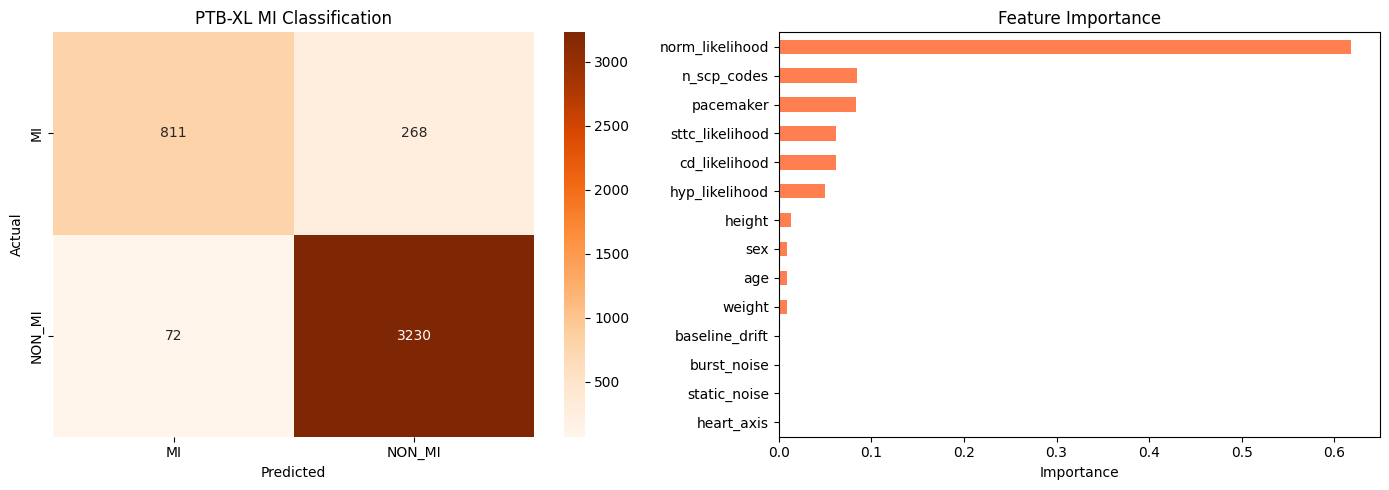

In [11]:
y_pred = xgb_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

# Confusion Matrix + Feature Importance
cm = confusion_matrix(y_test_enc, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("PTB-XL MI Classification")

importance = pd.Series(xgb_model.feature_importances_, index=features)
importance.sort_values(ascending=True).plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Feature Importance")
axes[1].set_xlabel("Importance")
plt.tight_layout()
plt.show()


In [12]:
os.makedirs("saved_models", exist_ok=True)

joblib.dump(xgb_model, "saved_models/ptb_xgb_model_bk.pkl")
print("Model saved: saved_models/ptb_xgb_model_bk.pkl")

joblib.dump(le, "saved_models/ptb_label_encoder_bk.pkl")
print("Encoder saved: saved_models/ptb_label_encoder_bk.pkl")

# Verify
loaded = joblib.load("saved_models/ptb_xgb_model_bk.pkl")
test_pred = loaded.predict(X_test[:5])
print(f"Verification: {le.inverse_transform(test_pred)}")


Model saved: saved_models/ptb_xgb_model_bk.pkl
Encoder saved: saved_models/ptb_label_encoder_bk.pkl
Verification: ['MI' 'NON_MI' 'NON_MI' 'MI' 'NON_MI']
